# Following the money: who moves it, and who looks like they might

> AI assistance (GitHub Copilot) was used for brainstorming and code in this notebook.

This notebook picks up where `lda_irs_link.ipynb` left off. That notebook did the slow work of matching lobbying registrants to their IRS identities. Here we use that crosswalk to ask a harder question. We already know a handful of organizations that act as dark-money conduits. Can we find others that behave the same way but haven't been named yet?

Run the linking notebook first. It writes `high_conf_matches` and `irs_entities_addr` into `data/linking_outputs/`. The two setup cells below rebuild the DuckDB views over the S3 data and reload those tables, so this notebook runs on its own and doesn't need the other one's kernel.


In [186]:
%matplotlib inline
# DuckDB connection, S3 views, and shared matching helpers.
from pathlib import Path
import re as _re
import duckdb
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PARQUET_BASE = "s3://irs-990-263839540825-us-east-2-an/parquet_updated"
AWS_REGION = "us-east-2"
LINK_EXPORT_DIR = ROOT / "data" / "linking_outputs"
TRANSPARENCY_INDEX_PATH = f"{PARQUET_BASE}/transparency_index_scores/transparency_index__*.parquet"

conn = duckdb.connect(database=":memory:")
conn.execute("INSTALL httpfs; LOAD httpfs;")
conn.execute(f"""
    CREATE SECRET s3_access (
        TYPE s3,
        PROVIDER credential_chain,
        REGION '{AWS_REGION}'
    )
""")

for table in (
    "organizations",
    "irs_master",
    "irs990_filings",
    "irs990_filing_related_orgs",
    "irs990_filing_527_orgs",
    "irs990_filing_grants",
    "irs990_filing_people",
    "irs990_filing_related_org_transactions",
    "irs990_filing_contractors",
    "irs990_filing_lobbying",
    "lobbying_bill_links",
    "lda_filings",
    "lda_lobbying_activities",
    "entity_observations",
):
    conn.execute(f"""
        CREATE OR REPLACE VIEW {table} AS
        SELECT *
        FROM read_parquet(
            '{PARQUET_BASE}/{table}/*.parquet',
            union_by_name = true
        )
    """)

def q(sql):
    return conn.execute(sql).df()


def name_block_on(a, b):
    """Blocking predicate for near-name joins: shared 8-char prefix and >=60% length ratio."""
    return (
        f"LEFT({a}, 8) = LEFT({b}, 8)\n"
        f"     AND LEAST(LENGTH({a}), LENGTH({b}))::DOUBLE\n"
        f"         / GREATEST(LENGTH({a}), LENGTH({b})) >= 0.60"
    )

def tier_case(prefix="name"):
    """Strongest-evidence label from the zip_agrees / state_agrees booleans."""
    return (
        "CASE "
        f"WHEN zip_agrees THEN '{prefix} + state + zip' "
        f"WHEN state_agrees THEN '{prefix} + state' "
        f"ELSE '{prefix} only' END"
    )

In [187]:
# Reload the crosswalk produced by the linking notebook and rebuild the
# EIN-to-filing bridge the network and modeling sections depend on.
conn.execute(f"""
CREATE OR REPLACE TEMP TABLE high_conf_matches AS
SELECT * FROM read_parquet('{(LINK_EXPORT_DIR / "high_conf_matches.parquet").as_posix()}')
""")
conn.execute(f"""
CREATE OR REPLACE TEMP TABLE irs_entities_addr AS
SELECT * FROM read_parquet('{(LINK_EXPORT_DIR / "irs_entities_addr.parquet").as_posix()}')
""")
high_conf_matches = q("SELECT * FROM high_conf_matches")

# Downstream detail tables join to matched EINs through filing_id.
conn.execute("""
CREATE OR REPLACE TEMP TABLE matched_ein_filings AS
SELECT DISTINCT filing.filing_id, filing.ein
FROM irs990_filings AS filing
JOIN (SELECT DISTINCT ein FROM high_conf_matches) AS matched USING (ein)
""")

print(
    f"Loaded crosswalk: {len(high_conf_matches):,} links, "
    f"{high_conf_matches['ein'].nunique():,} distinct EINs"
)

Loaded crosswalk: 5,416 links, 2,910 distinct EINs


# Two ways these organizations connect

Money isn't the only thread tying these groups together, so we start with two networks over the matched cohort.

The first one follows the money. It's a directed graph where an edge means one organization granted funds to another, weighted by the dollars involved. PageRank over that graph surfaces the organizations sitting downstream of the most influential money.

The second one follows shared attention. Two organizations get linked when they lobby the same bills. We drop any bill touched by more than a hundred groups, since those crowded bills connect everyone to everyone and tell us nothing. What's left points to the central players, the brokers that bridge otherwise separate camps, and the natural issue-based communities.


In [188]:
import math
import networkx as nx
import pandas as pd
try:
    import community as community_louvain
except Exception:
    community_louvain = None

# EIN -> IRS name label map for readable node output.
ein_name = dict(high_conf_matches.drop_duplicates("ein")[["ein", "irs_name"]].values)

# ---- Funding network: grantor EIN -> grantee EIN, both inside the matched cohort ----
funding_edges = q("""
SELECT mf.ein AS src_ein, g.grantee_ein AS dst_ein,
       COUNT(*) AS n_grants, SUM(TRY_CAST(g.amount AS DOUBLE)) AS total_amount
FROM irs990_filing_grants g
JOIN matched_ein_filings mf USING (filing_id)
WHERE g.grantee_ein IN (SELECT DISTINCT ein FROM high_conf_matches)
  AND g.grantee_ein <> mf.ein
GROUP BY mf.ein, g.grantee_ein
""")

FG = nx.DiGraph()
for r in funding_edges.itertuples(index=False):
    amt = float(r.total_amount or 0.0)
    if not math.isfinite(amt) or amt < 0:
        amt = 0.0
    FG.add_edge(r.src_ein, r.dst_ein, weight=math.log1p(amt), amount=amt, n=int(r.n_grants))
# log-scaled weights keep PageRank stable across the huge dollar range.
f_pagerank = nx.pagerank(FG, weight="weight", max_iter=500)
f_dollars_in = dict(FG.in_degree(weight="amount"))
funding_top = (
    pd.DataFrame({"ein": list(f_pagerank), "pagerank": list(f_pagerank.values())})
    .assign(org=lambda d: d.ein.map(ein_name),
            dollars_received=lambda d: d.ein.map(f_dollars_in))
    .sort_values("pagerank", ascending=False).head(15)
)
print(f"Funding network: {FG.number_of_nodes():,} orgs, {FG.number_of_edges():,} edges")
display(funding_top[["org", "ein", "pagerank", "dollars_received"]])

# ---- Co-lobbying network: orgs linked by shared bills (cap mega-bills to keep it sparse) ----
org_bill = q("""
WITH client_ein AS (SELECT DISTINCT lda_key, ein FROM high_conf_matches WHERE role = 'client'),
     client_filings AS (
        SELECT json_extract_string(raw_json, '$.client.id') AS lda_key, filing_uuid
        FROM lda_filings WHERE json_valid(raw_json)),
     ob AS (
        SELECT DISTINCT ce.ein AS ein,
               bl.bill_type || CAST(bl.bill_number AS VARCHAR) AS bill
        FROM client_ein ce
        JOIN client_filings cf USING (lda_key)
        JOIN lobbying_bill_links bl USING (filing_uuid)
        WHERE bl.bill_number IS NOT NULL),
     bill_deg AS (SELECT bill, COUNT(*) AS n_orgs FROM ob GROUP BY bill)
SELECT ob.ein, ob.bill
FROM ob JOIN bill_deg USING (bill)
WHERE bill_deg.n_orgs BETWEEN 2 AND 100
""")

orgs = org_bill.ein.unique().tolist()
B = nx.Graph()
B.add_nodes_from(orgs, bipartite=0)
B.add_nodes_from(org_bill.bill.unique().tolist(), bipartite=1)
B.add_edges_from(map(tuple, org_bill[["ein", "bill"]].values))
CL = nx.bipartite.weighted_projected_graph(B, orgs)

c_pagerank = nx.pagerank(CL, weight="weight", max_iter=500)
c_betweenness = nx.betweenness_centrality(CL, k=min(300, CL.number_of_nodes()), seed=1)
parts = community_louvain.best_partition(CL, weight="weight") if community_louvain else {}
colobby_top = (
    pd.DataFrame({"ein": list(c_pagerank)})
    .assign(org=lambda d: d.ein.map(ein_name),
            pagerank=lambda d: d.ein.map(c_pagerank),
            betweenness=lambda d: d.ein.map(c_betweenness),
            community=lambda d: d.ein.map(parts))
    .sort_values("pagerank", ascending=False).head(15)
)
n_comm = len(set(parts.values())) if parts else 0
print(f"\nCo-lobbying network: {CL.number_of_nodes():,} orgs, {CL.number_of_edges():,} edges, {n_comm} communities")
display(colobby_top[["org", "ein", "pagerank", "betweenness", "community"]])


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Funding network: 1,502 orgs, 7,368 edges


,org,ein,pagerank,dollars_received
339,UNIVERSITY OF NORTH CAROLINA AT CHAPEL HILL,566001393,0.009877,4.853527e+08
0,JOHNS HOPKINS UNIVERSITY,520595110,0.007995,9.144888e+08
128,MARCH OF DIMES INC,131846366,0.007977,6.287121e+06
47,TRUSTEES OF THE UNIVERSITY OF PENNSYLVANIA,231352685,0.006594,4.106726e+08
53,New York University,135562308,0.006394,3.182190e+08
188,UNIVERSITY OF SOUTHERN CALIFORNIA,951642394,0.005767,4.646156e+08
61,THE TRUSTEES OF COLUMBIA UNIVERSITY IN THE CIT...,135598093,0.005236,2.497808e+08
65,DUKE UNIVERSITY,560532129,0.005227,5.755696e+08
71,The Regents of the University of California,943067788,0.005143,3.309717e+09
81,Yale University,060646973,0.004958,2.773920e+08


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Co-lobbying network: 1,288 orgs, 72,923 edges, 8 communities


,org,ein,pagerank,betweenness,community
86,Chamber of Commerce of the USA,530045720,0.013224,0.059737,1
5,NATIONAL TREASURY EMPLOYEES UNION,530244795,0.007932,0.015754,3
124,Americans for the Arts Inc,521996467,0.007223,0.025305,0
98,AMERICAN CIVIL LIBERTIES UNION OF THE DISTRICT...,520749684,0.006956,0.019304,4
6,HERITAGE ACTION FOR AMERICA,272244700,0.006067,0.017324,4
220,AMERICANS FOR AMERICA Inc,844275594,0.006055,0.017360,6
126,National League for Nursing,131896510,0.005875,0.020259,6
114,HUMAN RIGHTS CAMPAIGN INC,521243457,0.005773,0.007817,3
87,AMERICAN CENTER,474245571,0.005671,0.020187,3
213,AMERICAN CHEMISTRY COUNCIL,530104410,0.005601,0.009196,7


## Zooming out to the whole money web

The cohort above is small on purpose. To see where our known dark-money groups actually sit, we rebuild the grant network for every filer in 2023 and 2024. That is hundreds of thousands of organizations and every funder-to-grantee edge we can find, each weighted by amount.

The OpenSecrets dark-money list rides along inside that web as a labeled subset. Weighted PageRank tells us how central those known groups really are, and it sets up the personalized PageRank idea we use later to find organizations that sit in similar spots.


In [189]:
# Build the FULL 2023/24 money-flow network (all EINs) and rank by weighted PageRank; seeds are a labeled subset.
import networkx as nx
import numpy as np, pandas as pd

YEARS = "(2023, 2024)"  # tax years for the money-flow network

# Repeated-digit EINs (000000000, 999999999, 111111111, ...) are redaction sentinels filers enter
# for a missing grantee, not real orgs; their inbound edges are artificial, so drop them up front.
PLACEHOLDER_EINS = tuple(str(d) * 9 for d in range(10))
_ph_sql = "(" + ", ".join(f"'{e}'" for e in PLACEHOLDER_EINS) + ")"

# Dark-money seeds loaded from the maintained S3 label file.
conn.execute(f"""CREATE OR REPLACE TEMP TABLE dark_money AS
    SELECT DISTINCT
        LPAD(CAST(filer_ein AS VARCHAR), 9, '0') AS ein,
        filer_name AS crp_name
    FROM read_parquet('{PARQUET_BASE}/dark_money_labels.parquet')
    WHERE filer_ein IS NOT NULL""")

# ALL directed grant edges (funder -> grantee) for 2023/24 -- the entire money web, not just seed-adjacent.
# Drop placeholder redaction EINs from both ends so they don't form artificial hubs.
edges = q(f"""
WITH fy AS (SELECT filing_id, ein FROM irs990_filings WHERE TRY_CAST(tax_year AS INT) IN {YEARS})
SELECT fy.ein AS src, g.grantee_ein AS dst, SUM(TRY_CAST(g.amount AS DOUBLE)) AS amt
FROM irs990_filing_grants g JOIN fy USING (filing_id)
WHERE g.grantee_ein IS NOT NULL AND g.grantee_ein <> fy.ein
  AND fy.ein NOT IN {_ph_sql}
  AND g.grantee_ein NOT IN {_ph_sql}
GROUP BY 1, 2
HAVING SUM(TRY_CAST(g.amount AS DOUBLE)) > 0
""")

seed_set = set(conn.execute("SELECT ein FROM dark_money").df().ein)
crp_name = conn.execute("SELECT ein, crp_name FROM dark_money").df().set_index("ein")["crp_name"].to_dict()
org_name = q("SELECT ein, current_name AS name FROM organizations").set_index("ein")["name"].to_dict()
nm = lambda e: (crp_name.get(e) or org_name.get(e) or e)

G = nx.from_pandas_edgelist(edges, "src", "dst", edge_attr="amt", create_using=nx.DiGraph)
pr = nx.pagerank(G, weight="amt")

rank = (pd.DataFrame({"ein": list(G.nodes)})
        .assign(is_seed=lambda d: d.ein.isin(seed_set).astype(int),
                pagerank=lambda d: d.ein.map(pr),
                dollars_in=lambda d: d.ein.map(dict(G.in_degree(weight="amt"))),
                dollars_out=lambda d: d.ein.map(dict(G.out_degree(weight="amt"))),
                in_deg=lambda d: d.ein.map(dict(G.in_degree())),
                out_deg=lambda d: d.ein.map(dict(G.out_degree())))
        .sort_values("pagerank", ascending=False))
rank["name"] = rank.ein.map(nm)
rank["pr_pctile"] = rank.pagerank.rank(pct=True)

n_seed = int(rank.is_seed.sum())
print(f"FULL money web: nodes {G.number_of_nodes():,}   edges {G.number_of_edges():,}   "
      f"total grant $ {edges.amt.sum():,.0f}")
print(f"seeds present {n_seed}/{len(seed_set)}")
print(f"\nSeed centrality within the FULL web (PageRank percentile, 1.0 = most central):")
print(f"  OpenSecrets seeds : median {rank.loc[rank.is_seed==1,'pr_pctile'].median():.3f}  "
      f"mean {rank.loc[rank.is_seed==1,'pr_pctile'].mean():.3f}")
print(f"  everyone else     : median {rank.loc[rank.is_seed==0,'pr_pctile'].median():.3f}  "
      f"mean {rank.loc[rank.is_seed==0,'pr_pctile'].mean():.3f}")

print("\nTop 15 OpenSecrets seeds by PageRank within the full web:")
display(rank[rank.is_seed == 1].head(15)[
    ["name", "pagerank", "pr_pctile", "dollars_in", "dollars_out", "in_deg", "out_deg"]])
print("Top 15 orgs overall by PageRank (largest hubs in the entire money web):")
display(rank.head(15)[["name", "is_seed", "pagerank", "dollars_in", "dollars_out", "in_deg", "out_deg"]])


FULL money web: nodes 436,174   edges 1,184,318   total grant $ 332,058,109,115
seeds present 258/329

Seed centrality within the FULL web (PageRank percentile, 1.0 = most central):
  OpenSecrets seeds : median 0.902  mean 0.795
  everyone else     : median 0.500  mean 0.500

Top 15 OpenSecrets seeds by PageRank within the full web:


,name,pagerank,pr_pctile,dollars_in,dollars_out,in_deg,out_deg
4168,AMERICAN ACADEMY OF OPHTHALMOLOGY INC,0.000017,0.999353,23329505.0,3091619.0,11,26
9914,America Votes,0.000013,0.999010,185941769.0,202398323.0,54,129
7572,SIXTEEN THIRTY FUND,0.000012,0.998927,220079661.0,342830502.0,42,422
11882,CREDIT UNION NATIONAL ASSOCIATION INC,0.000011,0.998760,631619.0,800000.0,9,1
7443,LEAGUE OF CONSERVATION VOTERS INC,0.000011,0.998652,120551953.0,116924914.0,38,108
32,NATIONAL WILDLIFE FEDERATION,0.000010,0.998340,22470223.0,19578081.0,93,148
46055,WORKING AMERICA,0.000009,0.997976,60924596.0,2500000.0,17,1
31762,SIERRA CLUB,0.000008,0.997214,188937808.0,1284504.0,24,75
115431,VOTEVETS ACTION FUND INC,0.000007,0.996600,8080000.0,11555000.0,16,4
17910,THIRD WAY,0.000006,0.995479,43373975.0,2126000.0,14,10


Top 15 orgs overall by PageRank (largest hubs in the entire money web):


,name,is_seed,pagerank,dollars_in,dollars_out,in_deg,out_deg
1934,HABITAT FOR HUMANITY INTERNATIONAL INC,0,0.000147,4.480632e+07,1.337985e+08,195,786
28,NATL CHRISTIAN CHARITABLE FDN INC,0,0.000109,1.095042e+09,4.475845e+09,144,19755
16156,THE ROTARY FOUNDATION OF ROTARY INTERNATIONAL,0,0.000097,1.532535e+07,4.663529e+07,184,391
2298,THE JEWISH FEDERATIONS OF NORTH AMERICA INC,0,0.000097,8.311771e+08,9.755670e+08,200,196
3323,THE BOARD OF TRUSTEES OF THE LELAND STANFORD J...,0,0.000091,1.133839e+09,7.462135e+07,461,115
10159,President and Fellows of Harvard College,0,0.000086,6.798390e+08,4.507237e+08,374,447
1564,JOHNS HOPKINS UNIVERSITY,0,0.000086,1.785949e+09,1.058253e+09,444,994
7588,DUKE UNIVERSITY,0,0.000083,3.856273e+09,8.018139e+06,400,148
1086,TRUSTEES OF THE UNIVERSITY OF PENNSYLVANIA,0,0.000083,4.431519e+08,2.910091e+07,428,151
3063,THE TRUSTEES OF COLUMBIA UNIVERSITY IN THE CIT...,0,0.000082,3.684877e+08,3.894349e+08,425,528


### Where the known groups sit in the web

The medians above only summarise the story. The two charts below show the whole distribution. If the labels carried no signal, their percentiles would look flat, like everyone else's. Instead the known dark-money groups pile up toward the high end, and the cumulative curve pulls well away from the no-signal diagonal, so being a known conduit really does line up with sitting near the centre of the money web.


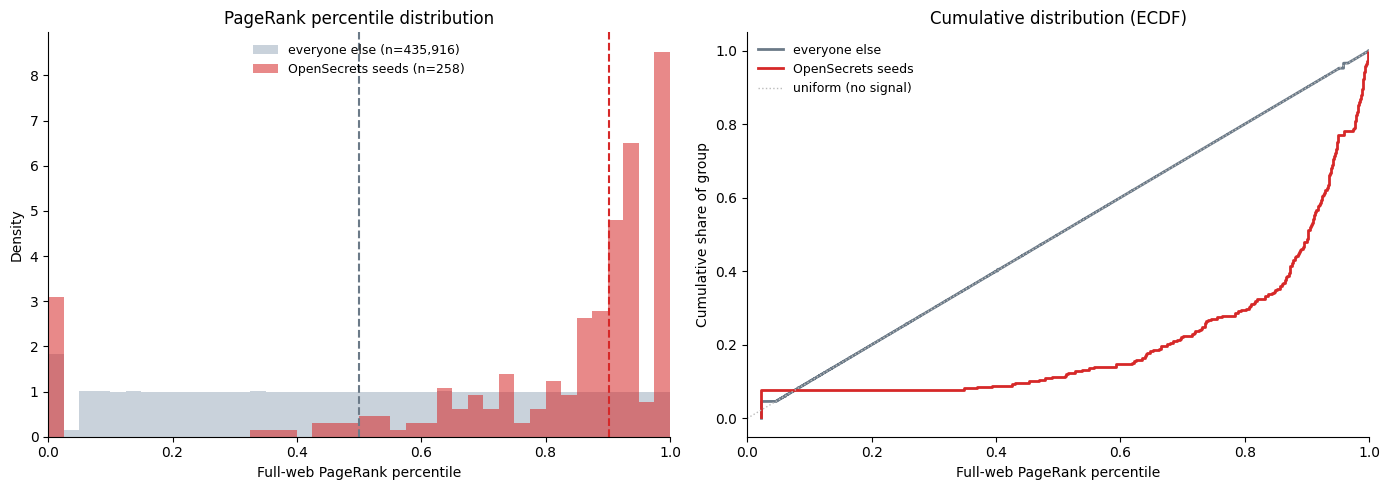

Median PageRank percentile: seeds 0.902 vs everyone else 0.500
Share landing in the top 10% of the web by PageRank: seeds 51.6% vs everyone else 10.0%


In [190]:
# Distribution of full-web PageRank percentiles: known dark-money seeds vs. everyone else.
import matplotlib.pyplot as plt
import numpy as np

seed_pct = rank.loc[rank.is_seed == 1, "pr_pctile"].dropna().to_numpy()
rest_pct = rank.loc[rank.is_seed == 0, "pr_pctile"].dropna().to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.linspace(0, 1, 41)
axes[0].hist(rest_pct, bins=bins, density=True, color="#B8C4D0", alpha=0.75,
             label=f"everyone else (n={len(rest_pct):,})")
axes[0].hist(seed_pct, bins=bins, density=True, color="#D62828", alpha=0.55,
             label=f"OpenSecrets seeds (n={len(seed_pct):,})")
axes[0].axvline(np.median(rest_pct), color="#6B7A88", linestyle="--", linewidth=1.5)
axes[0].axvline(np.median(seed_pct), color="#D62828", linestyle="--", linewidth=1.5)
axes[0].set_title("PageRank percentile distribution")
axes[0].set_xlabel("Full-web PageRank percentile")
axes[0].set_ylabel("Density")
axes[0].legend(frameon=False, fontsize=9, loc="upper center")

# ECDF makes the seeds' rightward shift explicit; the diagonal is what a uniform (no-signal) set would give.
for values, color, label in [(rest_pct, "#6B7A88", "everyone else"),
                             (seed_pct, "#D62828", "OpenSecrets seeds")]:
    xs = np.sort(values)
    ys = np.arange(1, len(xs) + 1) / len(xs)
    axes[1].step(xs, ys, where="post", color=color, linewidth=2, label=label)
axes[1].plot([0, 1], [0, 1], color="#BBBBBB", linestyle=":", linewidth=1, label="uniform (no signal)")
axes[1].set_title("Cumulative distribution (ECDF)")
axes[1].set_xlabel("Full-web PageRank percentile")
axes[1].set_ylabel("Cumulative share of group")
axes[1].legend(frameon=False, fontsize=9, loc="upper left")

for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
    axis.set_xlim(0, 1)

fig.tight_layout()
plt.show()

print(f"Median PageRank percentile: seeds {np.median(seed_pct):.3f} vs everyone else {np.median(rest_pct):.3f}")
print(f"Share landing in the top 10% of the web by PageRank: "
      f"seeds {(seed_pct >= 0.90).mean():.1%} vs everyone else {(rest_pct >= 0.90).mean():.1%}")


## Narrowing the field before we model

Our first instinct was to score all 436,000 organizations, and it backfired. The model handed high marks to hospitals, universities, and seminaries, just because large institutions move money in ways that look a little like a conduit. Scoring that far outside what the model had learned wasn't trustworthy.

So we split the difference. The structural measures (degree, dollars in and out, global PageRank) still come from the full web, because a node's position only means something in the whole graph. But the candidate pool shrinks to the known dark-money groups plus everyone within one grant hop of them. Those neighbors are the hard negatives. They are close enough to be genuinely confusable, which is what makes them a fair test.

The model weighs four kinds of evidence: where an organization sits structurally, how it behaves with its money and legal status, how political its funding neighbors are, and how close it lands to the other known seeds (computed without ever letting an org see its own label). We report cross-validated AUC next to the train-test gap, then rank the unlabeled organizations by their out-of-fold probability.


In [191]:
# Model on the seed-connected money neighborhood within the full web; full-web features + leak-free LOO-PPR proximity.
import numpy as np, pandas as pd, networkx as nx
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
# Regularized, imbalance-aware booster (reused by every modelling cell below).
# Shallow trees + low learning rate + L2 + subsample-of-features cut the old train/test
# overfitting gap (~0.10); class_weight='balanced' lifts PR-AUC on the ~6% positive pool.
def GBC():
    return HistGradientBoostingClassifier(
        loss='log_loss', learning_rate=0.05, max_iter=300,
        max_leaf_nodes=15, min_samples_leaf=20, l2_regularization=1.0,
        max_features=0.8, early_stopping=False,
        class_weight='balanced', random_state=42,
    )

# Candidate pool = seeds + their 1-hop grant partners within the FULL web (hard negatives).
pool = {n for n in G.nodes if n in seed_set}
for s in list(pool):
    pool |= set(G.predecessors(s)) | set(G.successors(s))
Gp = G.subgraph(pool).copy()
nodes = list(Gp.nodes)
node_ix = {n: i for i, n in enumerate(nodes)}
y = np.array([1 if n in seed_set else 0 for n in nodes], dtype=int)

# --- structural features computed over the ENTIRE web (degree, dollars, global PageRank) ---
S = pd.DataFrame({"ein": nodes})
S["in_deg"]  = S.ein.map(dict(G.in_degree()));  S["out_deg"] = S.ein.map(dict(G.out_degree()))
din  = S.ein.map(dict(G.in_degree(weight="amt"))).values
dout = S.ein.map(dict(G.out_degree(weight="amt"))).values
S["log_d_in"] = np.log1p(din); S["log_d_out"] = np.log1p(dout)
S["conduit"] = np.where((din > 0) & (dout > 0), np.minimum(din, dout) / np.maximum(np.maximum(din, dout), 1), 0.0)
S["deg"] = S.in_deg + S.out_deg

# --- behaviour features for the pool (fy scopes every source to the same YEARS window as the graph) ---
# is_527: Schedule C line 5 lists section-527 orgs a filer paid, but filers mis-enter 501(c) orgs there.
# A real 527 files Form 8871/8872, not a 990, so exclude any named EIN that appears as a 990 filer.
# Exemption subsection is kept as flags (c3/c4/c5/c6 + an explicit "other") rather than dropping non-c3456
# orgs, which would also discard orgs with a missing type -- including several known seeds.
conn.register("g_nodes", pd.DataFrame({"ein": nodes}))
behav = q(f"""
WITH e AS (SELECT DISTINCT ein FROM g_nodes),
     fy AS (SELECT filing_id, ein, exempt_organization_type
            FROM irs990_filings
            WHERE TRY_CAST(tax_year AS INT) IN {YEARS}),
     rec AS (SELECT g.grantee_ein AS ein, SUM(TRY_CAST(g.amount AS DOUBLE)) received
             FROM irs990_filing_grants g JOIN fy USING (filing_id)
             WHERE g.grantee_ein IN (SELECT ein FROM e) GROUP BY g.grantee_ein),
     go AS (SELECT fy.ein, SUM(TRY_CAST(g.amount AS DOUBLE)) granted_out
            FROM fy JOIN irs990_filing_grants g USING (filing_id)
            WHERE fy.ein IN (SELECT ein FROM e) GROUP BY fy.ein),
     lob AS (SELECT DISTINCT fy.ein FROM fy JOIN irs990_filing_lobbying l USING (filing_id)
             WHERE fy.ein IN (SELECT ein FROM e)),
     p527 AS (SELECT DISTINCT ein FROM irs990_filing_527_orgs
              WHERE ein IN (SELECT ein FROM e)
                AND ein NOT IN (SELECT ein FROM irs990_filings WHERE ein IS NOT NULL)),
     eot AS (SELECT ein, mode(exempt_organization_type) AS et FROM fy
             WHERE ein IN (SELECT ein FROM e) AND exempt_organization_type IS NOT NULL GROUP BY ein)
SELECT e.ein, o.current_name AS name,
       COALESCE(rec.received,0) AS received, COALESCE(go.granted_out,0) AS granted_out,
       CASE WHEN lob.ein  IS NOT NULL THEN 1 ELSE 0 END AS has_lobbying,
       CASE WHEN p527.ein IS NOT NULL THEN 1 ELSE 0 END AS is_527,
       CASE WHEN eot.et = '501(c)(3)' THEN 1 ELSE 0 END AS eot_c3,
       CASE WHEN eot.et = '501(c)(4)' THEN 1 ELSE 0 END AS eot_c4,
       CASE WHEN eot.et = '501(c)(5)' THEN 1 ELSE 0 END AS eot_c5,
       CASE WHEN eot.et = '501(c)(6)' THEN 1 ELSE 0 END AS eot_c6,
       CASE WHEN eot.et IS NOT NULL
             AND eot.et NOT IN ('501(c)(3)', '501(c)(4)', '501(c)(5)', '501(c)(6)')
            THEN 1 ELSE 0 END AS eot_c_other
FROM e LEFT JOIN organizations o ON o.ein = e.ein
LEFT JOIN rec ON rec.ein = e.ein LEFT JOIN go ON go.ein = e.ein
LEFT JOIN lob ON lob.ein = e.ein LEFT JOIN p527 ON p527.ein = e.ein LEFT JOIN eot ON eot.ein = e.ein
""")
M = S.merge(behav, on="ein", how="left")
M["name"] = M.name.fillna(M.ein.map(lambda e: crp_name.get(e) or org_name.get(e) or e))
M["log_received"] = np.log1p(M.received); M["log_granted_out"] = np.log1p(M.granted_out)
M["velocity"]  = M.granted_out / (M.received + 1.0)
M["name_flag"] = M.name.fillna("").str.upper().str.contains(
    r"ACTION|\bFUND\b|PROJECT|ALLIANCE|NETWORK|VOTERS|FREEDOM|PROSPERITY").astype(int)

# political-neighbor feature: share of grant partners that are c4/c6/527 (IRS attributes, seeds removed -> leak-free)
# Same 527 correction: drop named 527-recipients that are actually 990 filers (mis-entered 501(c) orgs).
pol_set = set(q("""
    WITH c46 AS (SELECT DISTINCT ein FROM irs990_filings
                 WHERE exempt_organization_type IN ('501(c)(4)', '501(c)(6)','501(c)(5)')
                 And political_activity_flag = 1),
         p527 AS (SELECT DISTINCT ein FROM irs990_filing_527_orgs
                  WHERE ein NOT IN (SELECT ein FROM irs990_filings WHERE ein IS NOT NULL))
    SELECT ein FROM c46 UNION SELECT ein FROM p527
""").ein) - seed_set
def _pol_feats(n):
    succ = list(G.successors(n)); pred = list(G.predecessors(n))
    po = sum(1 for x in succ if x in pol_set); pi = sum(1 for x in pred if x in pol_set)
    return (po / len(succ) if succ else 0.0, pi / len(pred) if pred else 0.0, float(po + pi))
_pf = np.array([_pol_feats(n) for n in nodes])
M["pol_out_share"], M["pol_in_share"], M["pol_deg"] = _pf[:, 0], _pf[:, 1], _pf[:, 2]

STRUCTB = ["in_deg", "out_deg", "log_d_in", "log_d_out", "conduit", "deg"]
BEHAVB  = ["log_received", "log_granted_out", "velocity", "has_lobbying", "is_527",
           "name_flag", "eot_c3", "eot_c4", "eot_c5", "eot_c6", "eot_c_other"]
POL     = ["pol_out_share", "pol_in_share", "pol_deg"]
Xbase = M[STRUCTB + BEHAVB + POL].fillna(0).values

# --- single-source PPR from each seed on the pool graph, for leak-free LOO proximity ---
seeds_present = [n for n in nodes if n in seed_set]
Pmat = {}
for s in seeds_present:
    p = nx.pagerank(Gp, alpha=0.85, personalization={s: 1.0}, weight="amt", max_iter=500)
    Pmat[s] = np.array([p[n] for n in nodes])
diag = {s: Pmat[s][node_ix[s]] for s in seeds_present}

def prox(train_pos):   # proximity to OTHER seeds (leave-one-out): leak-free, symmetric for train & test
    a = np.zeros(len(nodes))
    for s in train_pos:
        a += Pmat[s]
    for s in train_pos:
        a[node_ix[s]] -= diag[s]
    return a

cv = StratifiedKFold(5, shuffle=True, random_state=42)
oof_base, oof_prox = np.zeros(len(nodes)), np.zeros(len(nodes))
for tr, te in cv.split(Xbase, y):
    tp = [nodes[i] for i in tr if y[i] == 1]
    Xp = np.column_stack([Xbase, prox(tp)])
    oof_base[te] = GBC().fit(Xbase[tr], y[tr]).predict_proba(Xbase[te])[:, 1]
    oof_prox[te] = GBC().fit(Xp[tr], y[tr]).predict_proba(Xp[te])[:, 1]

print(f"full web {G.number_of_nodes():,} orgs  |  candidate pool {len(nodes):,} "
      f"(seeds {int(y.sum())} + hard negatives {int((y==0).sum()):,})")
print(f"{'model':34s} {'OOF ROC-AUC':>11} {'OOF PR-AUC':>10}")
for tag, oof in [("structural + behaviour + political", oof_base), ("+ leave-one-out PPR proximity", oof_prox)]:
    print(f"{tag:34s} {roc_auc_score(y, oof):>11.3f} {average_precision_score(y, oof):>10.3f}")

tr, te = train_test_split(np.arange(len(nodes)), test_size=0.30, stratify=y, random_state=42)
Xp = np.column_stack([Xbase, prox([nodes[i] for i in tr if y[i] == 1])])
mdl = GBC().fit(Xp[tr], y[tr])
gtr = roc_auc_score(y[tr], mdl.predict_proba(Xp[tr])[:, 1]); gte = roc_auc_score(y[te], mdl.predict_proba(Xp[te])[:, 1])
print(f"held-out (LOO-PPR)  train {gtr:.3f}  test {gte:.3f}  gap {gtr - gte:.3f}")

M["score"] = oof_prox
M["is_seed"] = y
leads = M[M.is_seed == 0].sort_values("score", ascending=False).reset_index(drop=True)
print("\nTop 25 dark-money look-alikes (non-seed orgs in the pool, leak-free OOF score):")
display(leads.head(25)[["ein", "name", "score", "pol_out_share", "pol_in_share", "received", "granted_out",
                        "has_lobbying", "is_527", "eot_c3", "eot_c4", "eot_c5", "eot_c6", "eot_c_other"]])

# --- cache feature matrix + proximity for fast offline model iteration ---
try:
    import pickle as _pkl
    _cache = ROOT / 'data' / 'netcache'; _cache.mkdir(parents=True, exist_ok=True)
    with open(_cache / 'model_inputs.pkl', 'wb') as _f:
        _pkl.dump({'Xbase': Xbase, 'y': y, 'nodes': list(nodes),
                   'Pmat': {s: Pmat[s] for s in seeds_present},
                   'seeds_present': list(seeds_present), 'node_ix': node_ix,
                   'diag': diag, 'M': M,
                   'STRUCTB': STRUCTB, 'BEHAVB': BEHAVB, 'POL': POL}, _f)
    print(f'cached model inputs -> {_cache / "model_inputs.pkl"}')
except Exception as _e:
    print('cache skipped:', _e)


full web 436,174 orgs  |  candidate pool 4,395 (seeds 258 + hard negatives 4,137)
model                              OOF ROC-AUC OOF PR-AUC
structural + behaviour + political       0.867      0.321
+ leave-one-out PPR proximity            0.875      0.306
held-out (LOO-PPR)  train 0.999  test 0.864  gap 0.135

Top 25 dark-money look-alikes (non-seed orgs in the pool, leak-free OOF score):


,ein,name,score,pol_out_share,pol_in_share,received,granted_out,has_lobbying,is_527,eot_c3,eot_c4,eot_c5,eot_c6,eot_c_other
0,020226432,NEA - NEW HAMPSHIRE,0.987315,0.000000,1.000000,1631125.0,25000.0,1,0,0,0,0,1,0
1,921734450,DEMOCRACY SENTRY,0.977535,0.666667,1.000000,1030000.0,180000.0,0,0,0,1,0,0,0
2,833393572,PROGRESS ARIZONA,0.974059,0.200000,0.600000,3879568.0,475000.0,1,0,0,1,0,0,0
3,270637437,BOLD ALLIANCE INC,0.963414,0.000000,1.000000,125000.0,65750.0,1,0,0,1,0,0,0
4,825515918,CAMPAIGN FOR GREAT PUBLIC SCHOOLS,0.952708,0.533333,0.000000,1185000.0,31159289.0,1,0,0,1,0,0,0
5,521464785,AMERICAN TORT REFORM ASSOCIATION,0.950682,0.666667,0.500000,2040000.0,1840276.0,1,0,0,0,0,1,0
6,541641185,INSTITUTE FOR EDUCATIONAL REFORM INC,0.945474,0.000000,0.000000,0.0,10000.0,0,0,0,1,0,0,0
7,934932914,Defend Washington,0.942450,0.000000,0.600000,3847000.0,0.0,0,0,0,1,0,0,0
8,237076885,CHICAGO TEACHERS UNION FOUNDATION INC,0.939824,0.000000,1.000000,24375.0,117300.0,0,0,0,1,0,0,0
9,203338691,TAKEACTION MINNESOTA,0.939149,0.200000,0.470588,2060800.0,234337.0,1,0,0,1,0,0,0


cached model inputs -> c:\Users\kevallab\699\influence-network\data\netcache\model_inputs.pkl


### What tax status tells us

Before we look at any dollars, an organization's exemption subsection already says something about what it is for. Across the pool, comparing the share of each group that carries the flag:

- 501(c)(4): 79% of the known dark-money groups against 19% of the hard negatives, about four times as often. These social welfare groups can spend heavily on politics without naming donors. This is the strongest single flag.
- 501(c)(6): 11% of seeds versus 13% of negatives, basically even. Trade associations show up on both sides, so this flag only helps together with lobbying and conduit behaviour.
- 501(c)(3): 5% of seeds versus 46% of negatives. A low-c3 pool is what we would expect, since public charities disclose donors and are barred from most political spending.
- 501(c)(5): 1.2% of seeds versus 1.0% of negatives, no meaningful difference.

The `is_527` flag here marks non-filer 527 orgs that appear as recipients in Schedule C but do not themselves file a 990. By that definition seeds score 0% (they are 990 filers), so this flag is more useful as a network-neighbour signal than a direct org-level one.


In [192]:
# Showcase the exemption-subsection contrast: dark-money seeds vs. non-dark-money hard negatives.
flags = ["is_527", "eot_c3", "eot_c4", "eot_c5", "eot_c6", "eot_c_other"]
seed_rates = M.loc[y == 1, flags].mean()
neg_rates  = M.loc[y == 0, flags].mean()
profile = pd.DataFrame({
    "dark money (seed) %": (seed_rates * 100).round(1),
    "not dark money (neg) %": (neg_rates * 100).round(1),
    "lift (seed / neg)": (seed_rates / neg_rates.replace(0, np.nan)).round(2),
})
print(f"Exemption profile across {int((y==1).sum())} seeds vs {int((y==0).sum()):,} hard negatives:")
display(profile)

cols = ["ein", "name", "is_527", "eot_c3", "eot_c4", "eot_c5", "eot_c6", "eot_c_other", "has_lobbying", "score"]
print("\nDark-money examples (seeds carrying a c4/c6/527 political vehicle flag):")
display(M[(y == 1) & (M[["is_527", "eot_c4", "eot_c6"]].sum(axis=1) > 0)]
        .sort_values("score", ascending=False)[cols].head(10).reset_index(drop=True))

print("\nNon-dark-money examples (hard-negative c3 charities, the flag that pushes score down):")
display(M[(y == 0) & (M.eot_c3 == 1)]
        .sort_values("received", ascending=False)[cols].head(10).reset_index(drop=True))


Exemption profile across 258 seeds vs 4,137 hard negatives:


,dark money (seed) %,not dark money (neg) %,lift (seed / neg)
is_527,0.0,4.4,0.00
eot_c3,5.4,45.6,0.12
eot_c4,79.1,19.0,4.17
eot_c5,1.2,1.0,1.17
eot_c6,11.2,12.5,0.90
eot_c_other,0.8,0.4,1.89



Dark-money examples (seeds carrying a c4/c6/527 political vehicle flag):


,ein,name,is_527,eot_c3,eot_c4,eot_c5,eot_c6,eot_c_other,has_lobbying,score
0,651218474,POWERPAC ORG,0,0,1,0,0,0,1,0.983625
1,201597444,TRUMAN NATIONAL SECURITY PROJECT,0,0,1,0,0,0,0,0.974367
2,452600535,AMERICAN COMMITMENT,0,0,1,0,0,0,1,0.967644
3,270167620,FLORIDA RISING INC,0,0,1,0,0,0,1,0.964650
4,541564919,THE 60 PLUS ASSOCIATION INC,0,0,1,0,0,0,0,0.964410
5,993614737,Independent Veterans of America Action,0,0,1,0,0,0,1,0.961980
6,262731617,AMERICAN ENERGY ALLIANCE,0,0,1,0,0,0,0,0.961507
7,450710294,PATRIOT MAJORITY USA,0,0,1,0,0,0,0,0.961461
8,822007387,NATIONAL SECURITY ACTION,0,0,1,0,0,0,1,0.945045
9,820957528,NEW DEMOCRACY,0,0,1,0,0,0,1,0.938430



Non-dark-money examples (hard-negative c3 charities, the flag that pushes score down):


,ein,name,is_527,eot_c3,eot_c4,eot_c5,eot_c6,eot_c_other,has_lobbying,score
0,416011702,MAYO CLINIC,0,1,0,0,0,0,1,0.017893
1,560532129,DUKE UNIVERSITY,0,1,0,0,0,0,1,0.005269
2,237825575,NATIONAL PHILANTHROPIC TRUST,0,1,0,0,0,0,1,0.005256
3,110303001,FIDELITY INVESTMENTS CHARITABLE GIFT FUN,0,1,0,0,0,0,1,0.001288
4,135562308,New York University,0,1,0,0,0,0,1,0.040890
5,520595110,JOHNS HOPKINS UNIVERSITY,0,1,0,0,0,0,1,0.001695
6,311640316,DONOR ADVISED CHARITABLE GIVING INC,0,1,0,0,0,0,1,0.005124
7,941156365,THE BOARD OF TRUSTEES OF THE LELAND STANFORD J...,0,1,0,0,0,0,1,0.012806
8,581493949,NATL CHRISTIAN CHARITABLE FDN INC,0,1,0,0,0,0,0,0.000228
9,205205488,Silicon Valley Community Foundation,0,1,0,0,0,0,1,0.009972


## From model score to a shortlist

A high score means one thing: this organization moves money like the ones we already know. It does not mean the organization is political. Left alone, the ranking pushes up big institutions that just have unusual finances.

So before a name goes on a shortlist, we ask for a second reason to keep it. We count five signs of political relevance: reported lobbying, 527 status, (c)(4) status, (c)(6) status, and having at least a quarter of its grant partners be political organizations. If we require two of the five, most of the institutional noise drops out and we keep almost all of the known labels.

The table tries one, two, and three signals so you can see the trade-off between keeping real labels and dropping hard negatives. Two worked best. This is a filter applied after scoring, so it does not change the model or the scores.


Threshold: 0.495
                 pred not_dark   pred dark
  actual not_dark        3,750         387
  actual dark              110         148
  precision 0.277 | recall 0.574 | f1 0.373


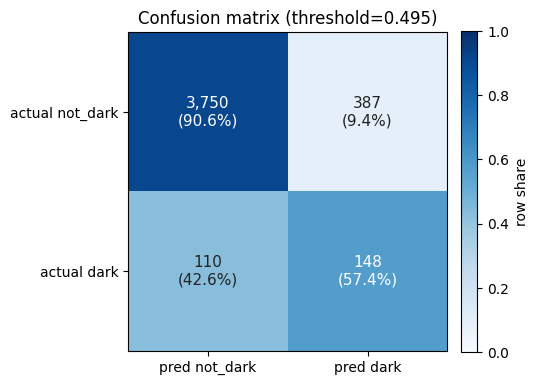

In [193]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

CLASSIFICATION_THRESHOLD = 0.495
pred = oof_prox >= CLASSIFICATION_THRESHOLD

tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
print(f"Threshold: {CLASSIFICATION_THRESHOLD}")
print(f"                 pred not_dark   pred dark")
print(f"  actual not_dark {tn:12,d}  {fp:10,d}")
print(f"  actual dark     {fn:12,d}  {tp:10,d}")
print(f"  precision {precision_score(y, pred):.3f} | recall {recall_score(y, pred):.3f} | f1 {f1_score(y, pred):.3f}")

cm = np.array([[tn, fp], [fn, tp]])
cm_norm = cm / cm.sum(axis=1, keepdims=True)
labels = ["not_dark", "dark"]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks([0, 1]); ax.set_xticklabels([f"pred {l}" for l in labels])
ax.set_yticks([0, 1]); ax.set_yticklabels([f"actual {l}" for l in labels])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}\n({cm_norm[i,j]:.1%})",
                ha="center", va="center", fontsize=11,
                color="white" if cm_norm[i,j] > 0.5 else "#222")
ax.set_title(f"Confusion matrix (threshold={CLASSIFICATION_THRESHOLD})")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="row share")
plt.tight_layout()
plt.show()


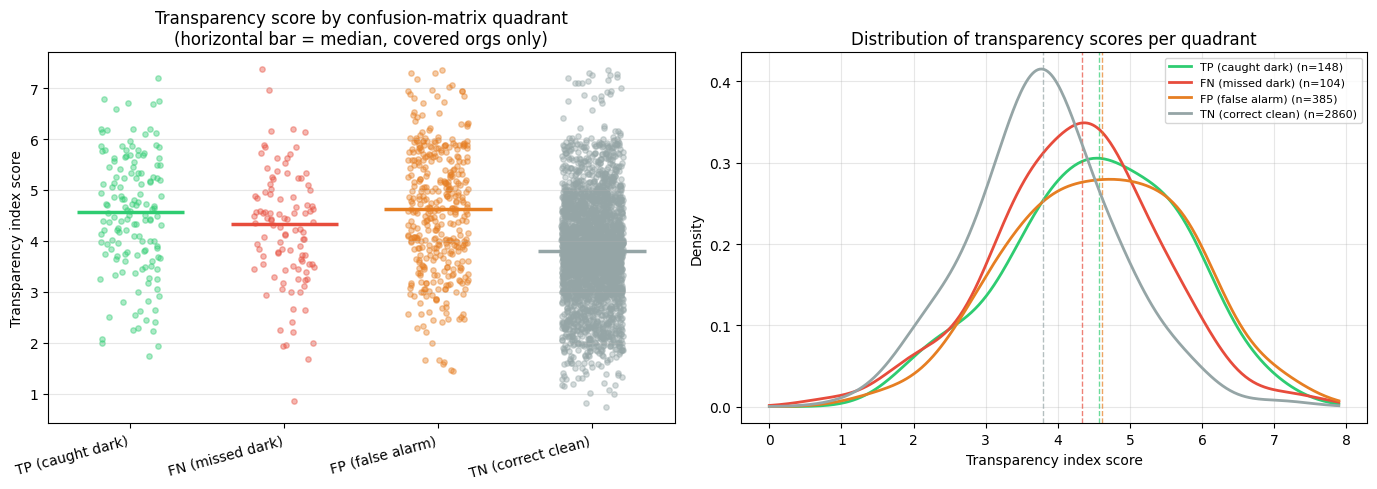


Transparency coverage and score by quadrant:


,total,with_ti,coverage,median_ti,mean_ti
quadrant,,,,,
TP (caught dark),148,148,100.0%,4.564,4.521
FN (missed dark),110,104,94.5%,4.336,4.227
FP (false alarm),387,385,99.5%,4.618,4.576
TN (correct clean),3750,2860,76.3%,3.791,3.798


In [194]:
# --- Transparency index position for each confusion-matrix quadrant ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

cm_labels = {
    "TP (caught dark)": (y == 1) & pred,
    "FN (missed dark)": (y == 1) & ~pred,
    "FP (false alarm)": (y == 0) & pred,
    "TN (correct clean)": (y == 0) & ~pred,
}
colors = {"TP (caught dark)": "#2ecc71", "FN (missed dark)": "#e74c3c",
          "FP (false alarm)": "#e67e22", "TN (correct clean)": "#95a5a6"}

# Join transparency scores onto M
ti = transparency[["ein", "normalized_index_score"]].drop_duplicates("ein")
Mti = M[["ein"]].copy()
Mti["ti_score"] = Mti.ein.map(ti.set_index("ein").normalized_index_score)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: strip / swarm plot of transparency scores per quadrant (covered orgs only)
ax = axes[0]
covered_groups = {}
for i, (label, mask) in enumerate(cm_labels.items()):
    scores = Mti.loc[mask, "ti_score"].dropna()
    covered_groups[label] = scores
    jitter = np.random.default_rng(i).uniform(-0.2, 0.2, len(scores))
    ax.scatter(np.full(len(scores), i) + jitter, scores,
               alpha=0.4, s=15, color=colors[label], label=label)
    ax.hlines(scores.median(), i - 0.35, i + 0.35,
              color=colors[label], linewidth=2.5)
ax.set_xticks(range(len(cm_labels)))
ax.set_xticklabels(list(cm_labels.keys()), rotation=15, ha="right")
ax.set_ylabel("Transparency index score")
ax.set_title("Transparency score by confusion-matrix quadrant\n(horizontal bar = median, covered orgs only)")
ax.grid(axis="y", alpha=0.3)

# Right: overlapping KDE / histogram of transparency percentile per quadrant
ax2 = axes[1]
from scipy.stats import gaussian_kde
all_scores = ti["normalized_index_score"].dropna()
xgrid = np.linspace(all_scores.min(), all_scores.max(), 300)
for label, scores in covered_groups.items():
    if len(scores) < 5:
        continue
    kde = gaussian_kde(scores, bw_method=0.4)
    ax2.plot(xgrid, kde(xgrid), color=colors[label], linewidth=2, label=f"{label} (n={len(scores)})")
    ax2.axvline(scores.median(), color=colors[label], linewidth=1, linestyle="--", alpha=0.7)
ax2.set_xlabel("Transparency index score")
ax2.set_ylabel("Density")
ax2.set_title("Distribution of transparency scores per quadrant")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\nTransparency coverage and score by quadrant:")
rows = []
for label, mask in cm_labels.items():
    scores = Mti.loc[mask, "ti_score"].dropna()
    total = int(mask.sum())
    rows.append({"quadrant": label, "total": total,
                 "with_ti": len(scores), "coverage": len(scores)/total if total else 0,
                 "median_ti": scores.median() if len(scores) else float("nan"),
                 "mean_ti": scores.mean() if len(scores) else float("nan")})
import pandas as pd
summary = pd.DataFrame(rows).set_index("quadrant")
display(summary.style.format(
    {"coverage": "{:.1%}", "median_ti": "{:.3f}", "mean_ti": "{:.3f}"}
).set_caption("Transparency index coverage and scores per confusion-matrix quadrant"))


In [195]:
# --- False Negatives: known dark-money seeds the model missed ---
fn_mask = (y == 1) & ~pred

fn_cols = [
    "ein", "name", "score",
    "conduit", "velocity",
    "in_deg", "out_deg",
    "pol_out_share", "pol_in_share",
    "has_lobbying", "is_527", "eot_c3", "eot_c4", "eot_c5", "eot_c6",
]
fn_df = M.loc[fn_mask, fn_cols].sort_values("score", ascending=False).reset_index(drop=True)

print(f"False negatives: {fn_mask.sum()} known seeds the model scored below {CLASSIFICATION_THRESHOLD}")
print(f"Score range among FNs: {fn_df.score.min():.3f} - {fn_df.score.max():.3f} "
      f"(median {fn_df.score.median():.3f})")
print()

# Why does the model miss them? Check structural signals.
tp_mask = (y == 1) & pred
print("Signal comparison: FN seeds vs TP seeds (medians)")
compare_cols = ["score", "conduit", "velocity", "in_deg", "out_deg",
                "pol_out_share", "pol_in_share", "has_lobbying", "is_527"]
comparison = (
    M.loc[fn_mask, compare_cols].median()
    .rename("FN (missed)")
    .to_frame()
    .join(M.loc[tp_mask, compare_cols].median().rename("TP (caught)"))
)
display(comparison.style.format("{:.3f}").set_caption("Median feature values: missed vs caught seeds"))

print("\nFull list of missed seeds:")
display(fn_df.style.format(
    {c: "{:.3f}" for c in ["score", "conduit", "velocity",
                           "pol_out_share", "pol_in_share"]}
).set_caption(f"False negatives @ threshold={CLASSIFICATION_THRESHOLD}"))


False negatives: 110 known seeds the model scored below 0.495
Score range among FNs: 0.000 - 0.492 (median 0.204)

Signal comparison: FN seeds vs TP seeds (medians)


,FN (missed),TP (caught)
score,0.204,0.776
conduit,0.029,0.000
velocity,0.147,0.075
in_deg,4.000,4.500
out_deg,1.500,1.000
pol_out_share,0.000,0.000
pol_in_share,0.333,0.500
has_lobbying,1.000,1.000
is_527,0.000,0.000



Full list of missed seeds:


,ein,name,score,conduit,velocity,in_deg,out_deg,pol_out_share,pol_in_share,has_lobbying,is_527,eot_c3,eot_c4,eot_c5,eot_c6
0,411709702,PLANNED PARENTHOOD MINNESOTA NORTH DAKOTA SOUTH DAKOTA ACTION FUND,0.492,0.139,0.139,2,1,1.000,0.000,1,0,0,1,0,0
1,881133984,MI PODER,0.492,0.000,0.000,6,0,0.000,0.333,0,0,0,1,0,0
2,852786747,LUPE VOTES,0.490,0.368,0.368,6,1,0.000,0.500,0,0,0,1,0,0
3,474435527,Black Youth Project 100 NFP,0.490,0.000,0.000,1,0,0.000,0.000,1,0,0,1,0,0
4,825528039,WAY TO WIN ACTION FUND INC,0.476,0.447,2.235,10,137,0.474,0.700,1,0,0,1,0,0
5,850549304,GOVERNING MAJORITY EDUCATION FUND,0.476,0.167,0.167,8,2,1.000,0.750,0,0,0,1,0,0
6,450518844,Jobs with Justice,0.463,0.658,0.658,7,8,0.500,0.714,0,0,0,1,0,0
7,135665571,INDEPENDENT INSURANCE AGENTS AND BROKERS OF AMERICA,0.452,0.160,6.250,1,2,0.000,1.000,1,0,0,0,0,1
8,132630359,REPRODUCTIVE FREEDOM FOR ALL,0.446,0.155,0.155,12,11,0.727,0.333,1,0,0,1,0,0
9,831769970,NEW AMERICAN LEADERS ACTION FUND INC,0.442,0.000,0.000,4,0,0.000,0.750,1,0,0,1,0,0


## Checking against the transparency index

We also compare against an outside measure. The transparency index scores how much each organization discloses. We join it by EIN, keep the most recent filing per organization, and line up the known dark-money groups against the rest of the pool.

Then we ask whether transparency adds anything the model did not already capture. Adding it as a feature moves ROC-AUC from 0.875 to 0.880 and PR-AUC from 0.306 to 0.312 -- a small but consistent bump. It is not transformative, but it is an independent check that points at the same organizations. Among the 387 false positives at the 0.495 threshold, the median transparency score is 4.6, right on the borderline, which tells us the model is not just picking up opaque institutions at random.

We treat the index as one more piece of evidence, not a verdict. A low score is a reason to look closer, not proof of anything.


In [196]:
# Latest transparency record per EIN within the IRS analysis years.
conn.execute(f"""
CREATE OR REPLACE VIEW transparency_index AS
SELECT *
FROM read_parquet(
    '{TRANSPARENCY_INDEX_PATH}',
    union_by_name=true
)
""")

transparency = q(f"""
WITH ranked AS (
    SELECT
        ein,
        tax_year,
        --filer_name,
        normalized_index_score,
        observed_components,
        complete,
        ROW_NUMBER() OVER (
            PARTITION BY ein
            ORDER BY tax_year DESC, filing_id DESC
        ) AS recency
    FROM transparency_index
    WHERE tax_year IN {YEARS}
)
SELECT * EXCLUDE recency
FROM ranked
WHERE recency = 1
""")

transparency_pool = (
    M[["ein", "name"]]
    .merge(transparency, on="ein", how="left")
    .assign(
        is_opensecrets=y,
        has_transparency=lambda frame: frame.normalized_index_score.notna().astype(int),
    )
)

transparency_summary = (
    transparency_pool.groupby("is_opensecrets")
    .agg(
        organizations=("ein", "size"),
        covered=("has_transparency", "sum"),
        coverage_rate=("has_transparency", "mean"),
        median_index_score=("normalized_index_score", "median"),
        mean_index_score=("normalized_index_score", "mean"),
        median_components=("observed_components", "median"),
        complete_rate=("complete", "mean"),
    )
    .rename(index={0: "other candidates", 1: "OpenSecrets"})
)

display(
    transparency_summary.style.format({
        "organizations": "{:,.0f}",
        "covered": "{:,.0f}",
        "coverage_rate": "{:.1%}",
        "median_index_score": "{:.3f}",
        "mean_index_score": "{:.3f}",
        "median_components": "{:.1f}",
        "complete_rate": "{:.1%}",
    })
)

# Missing records receive neutral values plus an explicit coverage indicator.
transparency_features = pd.DataFrame({
    "has_transparency": transparency_pool.has_transparency,
    "transparency_score": transparency_pool.normalized_index_score.fillna(
        transparency_pool.normalized_index_score.median()
    ),
    "transparency_components": transparency_pool.observed_components.fillna(0),
    "transparency_complete": transparency_pool.complete.fillna(0),
})
Xtransparency = np.column_stack([Xbase, transparency_features.values])

transparency_oof = {}
cv_transparency = StratifiedKFold(5, shuffle=True, random_state=42)
for label, feature_matrix in [
    ("full model", Xbase),
    ("full model + transparency", Xtransparency),
]:
    predictions = np.zeros(len(nodes))
    for train_rows, test_rows in cv_transparency.split(feature_matrix, y):
        training_seeds = [nodes[index] for index in train_rows if y[index] == 1]
        fold_matrix = np.column_stack([feature_matrix, prox(training_seeds)])
        predictions[test_rows] = GBC().fit(
            fold_matrix[train_rows], y[train_rows]
        ).predict_proba(fold_matrix[test_rows])[:, 1]
    transparency_oof[label] = predictions

print(f"{'feature set':30s} {'OOF ROC-AUC':>11} {'OOF PR-AUC':>10}")
for label, predictions in transparency_oof.items():
    print(
        f"{label:30s} "
        f"{roc_auc_score(y, predictions):>11.3f} "
        f"{average_precision_score(y, predictions):>10.3f}"
    )

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,organizations,covered,coverage_rate,median_index_score,mean_index_score,median_components,complete_rate
is_opensecrets,,,,,,,
other candidates,"4,137","3,245",78.4%,3.835,3.891,8.0,100.0%
OpenSecrets,258,252,97.7%,4.441,4.400,8.0,100.0%


feature set                    OOF ROC-AUC OOF PR-AUC
full model                           0.875      0.306
full model + transparency            0.880      0.312


In [197]:
transparency

,ein,tax_year,normalized_index_score,observed_components,complete
0,010018605,2024,3.967687,8,1
1,010018930,2024,2.660942,8,1
2,010052260,2024,3.583136,8,1
3,010096152,2024,3.537905,8,1
4,010114140,2024,4.880000,8,1
...,...,...,...,...,...
728662,270939300,2024,3.342782,8,1
728663,270940450,2024,3.635540,8,1
728664,270949759,2024,2.000000,8,1
728665,270950477,2024,3.779690,8,1


In [198]:
# Transparency review for unlabeled organizations classified as positive at the 0.50 threshold.
fp_transparency = transparency.copy()
fp_transparency["index_percentile"] = fp_transparency["normalized_index_score"].rank(pct=True)

CLASSIFICATION_THRESHOLD = 0.495
base_prediction = oof_prox >= CLASSIFICATION_THRESHOLD

review_columns = ["ein", "name", "score", "has_lobbying", "is_527", "eot_c4", "eot_c6"]
fp_mask = (y == 0) & base_prediction

transparency_cols = [
    "ein", "tax_year", "normalized_index_score", "index_percentile",
    "observed_components", "complete",
]
fp_review = (
    M.loc[fp_mask, review_columns]
    .merge(fp_transparency[transparency_cols], on="ein", how="left")
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)

transparency_fmt = {
    "score": "{:.3f}",
    "tax_year": "{:.0f}",
    "normalized_index_score": "{:.3f}",
    "index_percentile": "{:.1%}",
    "observed_components": "{:.0f}",
    "complete": "{:.0f}",
}

covered = fp_review["normalized_index_score"].notna()
print(f"False positives at threshold {CLASSIFICATION_THRESHOLD}: {fp_mask.sum()}")
print(
    f"Transparency coverage: {covered.sum()}/{len(fp_review)} ({covered.mean():.1%})"
)
if covered.any():
    scores = fp_review.loc[covered, "normalized_index_score"]
    print(f"Index score among covered: median {scores.median():.3f}; range {scores.min():.3f}-{scores.max():.3f}")

display(fp_review.style.format(transparency_fmt, na_rep="Not available"))


False positives at threshold 0.495: 387
Transparency coverage: 385/387 (99.5%)
Index score among covered: median 4.618; range 1.447-7.356


,ein,name,score,has_lobbying,is_527,eot_c4,eot_c6,tax_year,normalized_index_score,index_percentile,observed_components,complete
0,020226432,NEA - NEW HAMPSHIRE,0.987,1,0,0,1,2024,2.937,12.9%,8,1
1,921734450,DEMOCRACY SENTRY,0.978,0,0,1,0,2024,5.781,99.1%,8,1
2,833393572,PROGRESS ARIZONA,0.974,1,0,1,0,2024,6.035,99.9%,8,1
3,270637437,BOLD ALLIANCE INC,0.963,1,0,1,0,2024,5.162,94.7%,8,1
4,825515918,CAMPAIGN FOR GREAT PUBLIC SCHOOLS,0.953,1,0,1,0,2024,4.601,85.9%,8,1
5,521464785,AMERICAN TORT REFORM ASSOCIATION,0.951,1,0,0,1,2024,2.555,6.5%,8,1
6,541641185,INSTITUTE FOR EDUCATIONAL REFORM INC,0.945,0,0,1,0,2024,5.404,96.6%,8,1
7,934932914,Defend Washington,0.942,0,0,1,0,2024,4.760,89.1%,8,1
8,237076885,CHICAGO TEACHERS UNION FOUNDATION INC,0.940,0,0,1,0,2024,4.548,84.9%,8,1
9,203338691,TAKEACTION MINNESOTA,0.939,1,0,1,0,2024,3.953,66.8%,8,1


In [199]:
# Review transparency records for the highest-ranked non-seed model leads.
transparency_ranked = transparency.copy()
transparency_ranked["index_percentile"] = (
    transparency_ranked["normalized_index_score"].rank(pct=True)
)

model_lead_transparency = (
    leads.head(25)[["ein", "name", "score"]]
    .rename(columns={"score": "model_score"})
    .merge(
        transparency_ranked[[
            "ein",
            "tax_year",
            "normalized_index_score",
            "index_percentile",
            "observed_components",
            "complete",
        ]],
        on="ein",
        how="left",
    )
)
model_lead_transparency["has_transparency"] = (
    model_lead_transparency.normalized_index_score.notna()
)

covered_leads = int(model_lead_transparency.has_transparency.sum())
print(
    f"Transparency coverage for top 25 model leads: "
    f"{covered_leads}/25 ({covered_leads / 25:.1%})"
)

display(
    model_lead_transparency.style.format({
        "model_score": "{:.3f}",
        "tax_year": "{:.0f}",
        "normalized_index_score": "{:.3f}",
        "index_percentile": "{:.1%}",
        "observed_components": "{:.0f}",
        "complete": "{:.0f}",
    }, na_rep="Not available")
)

Transparency coverage for top 25 model leads: 25/25 (100.0%)


,ein,name,model_score,tax_year,normalized_index_score,index_percentile,observed_components,complete,has_transparency
0,020226432,NEA - NEW HAMPSHIRE,0.987,2024,2.937,12.9%,8,1,True
1,921734450,DEMOCRACY SENTRY,0.978,2024,5.781,99.1%,8,1,True
2,833393572,PROGRESS ARIZONA,0.974,2024,6.035,99.9%,8,1,True
3,270637437,BOLD ALLIANCE INC,0.963,2024,5.162,94.7%,8,1,True
4,825515918,CAMPAIGN FOR GREAT PUBLIC SCHOOLS,0.953,2024,4.601,85.9%,8,1,True
5,521464785,AMERICAN TORT REFORM ASSOCIATION,0.951,2024,2.555,6.5%,8,1,True
6,541641185,INSTITUTE FOR EDUCATIONAL REFORM INC,0.945,2024,5.404,96.6%,8,1,True
7,934932914,Defend Washington,0.942,2024,4.760,89.1%,8,1,True
8,237076885,CHICAGO TEACHERS UNION FOUNDATION INC,0.940,2024,4.548,84.9%,8,1,True
9,203338691,TAKEACTION MINNESOTA,0.939,2024,3.953,66.8%,8,1,True


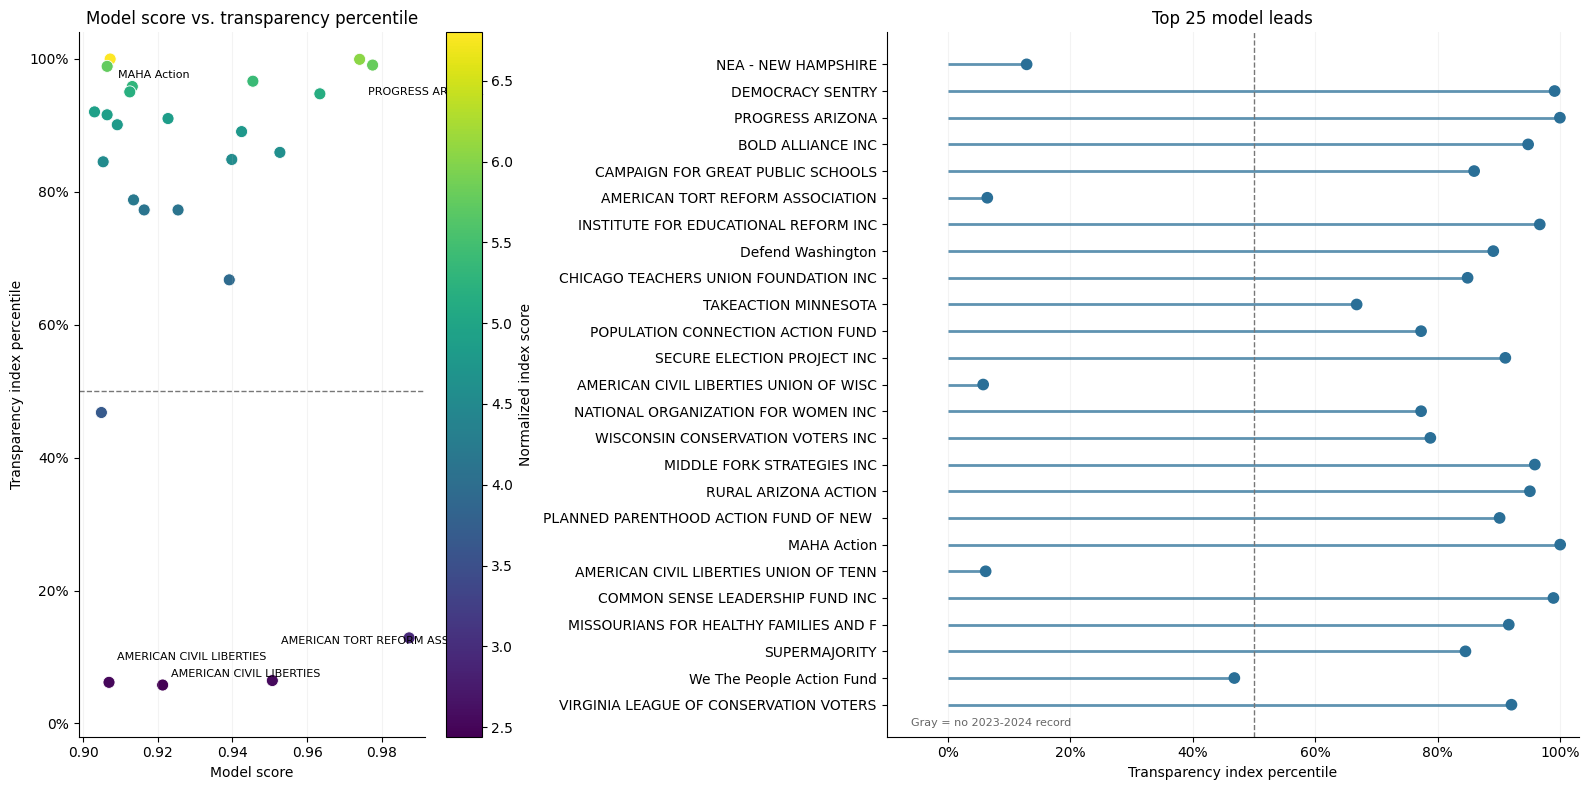

In [200]:
# Visual comparison of model rank and transparency index position.
import matplotlib.pyplot as plt

covered = model_lead_transparency[model_lead_transparency.has_transparency].copy()
plot_leads = model_lead_transparency.copy()
plot_leads["lead_label"] = plot_leads["name"].str.slice(0, 38)
plot_leads["plot_percentile"] = plot_leads.index_percentile.fillna(-0.06)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 8),
    gridspec_kw={"width_ratios": [1.0, 1.6]},
)

scatter = axes[0].scatter(
    covered.model_score,
    covered.index_percentile,
    c=covered.normalized_index_score,
    cmap="viridis",
    s=75,
    edgecolor="white",
    linewidth=0.6,
)
axes[0].axhline(0.5, color="#777777", linestyle="--", linewidth=1)
axes[0].set_title("Model score vs. transparency percentile")
axes[0].set_xlabel("Model score")
axes[0].set_ylabel("Transparency index percentile")
axes[0].set_ylim(-0.02, 1.04)
axes[0].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")

label_leads = pd.concat([
    covered.nlargest(2, "index_percentile"),
    covered.nsmallest(3, "index_percentile"),
]).drop_duplicates("ein")
high_index = 0
low_index = 0
for row in label_leads.itertuples(index=False):
    if row.index_percentile >= 0.5:
        offset = (6, -14 - high_index * 12)
        high_index += 1
    else:
        offset = (6, 6 + low_index * 10)
        low_index += 1
    axes[0].annotate(
        row.name[:24],
        (row.model_score, row.index_percentile),
        xytext=offset,
        textcoords="offset points",
        fontsize=8,
    )
fig.colorbar(scatter, ax=axes[0], label="Normalized index score")

rank_positions = np.arange(len(plot_leads))
point_colors = np.where(plot_leads.has_transparency, "#2A6F97", "#B8B8B8")
axes[1].hlines(
    rank_positions,
    xmin=0,
    xmax=plot_leads.plot_percentile.clip(lower=0),
    color=point_colors,
    linewidth=2,
    alpha=0.75,
)
axes[1].scatter(
    plot_leads.plot_percentile,
    rank_positions,
    color=point_colors,
    s=55,
    zorder=3,
)
axes[1].axvline(0.5, color="#777777", linestyle="--", linewidth=1)
axes[1].set_yticks(rank_positions, plot_leads.lead_label)
axes[1].invert_yaxis()
axes[1].set_xlim(-0.1, 1.03)
axes[1].set_xlabel("Transparency index percentile")
axes[1].set_title("Top 25 model leads")
axes[1].xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
axes[1].text(
    -0.06,
    len(plot_leads) - 0.2,
    "Gray = no 2023-2024 record",
    fontsize=8,
    color="#666666",
    ha="left",
)

for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
    axis.grid(axis="x", alpha=0.15)

fig.tight_layout()
plt.show()

## Seeing the connections

These two views show the shortlisted leads next to the known dark-money groups they grant to or receive from. The first covers the whole screened neighbourhood, and the second zooms in on the top few. Hover a node or an edge to see the grantor, the grantee, and the dollars between them.


In [201]:
# Interactive (Plotly) version of the screened-leads-vs-labels grant network.
import plotly.graph_objects as go
import networkx as nx

# Rebuild the same subgraph as the static figure: top-20 screened (non-seed) leads
# plus only the known-label seeds they directly grant to or receive from.
_name = M.set_index("ein").name.to_dict()
_prob = M.set_index("ein").score.to_dict()
_label = lambda n: (_name.get(n) or nm(n))
_dollars_in = dict(G.in_degree(weight="amt"))
_dollars_out = dict(G.out_degree(weight="amt"))

_top = set(leads.head(20).ein)
_keep = set(_top)
for _lead in _top:
    _keep.update(n for n in G.predecessors(_lead) if n in seed_set)
    _keep.update(n for n in G.successors(_lead) if n in seed_set)
H = G.subgraph(_keep).copy()
H.remove_nodes_from([n for n in list(H.nodes) if H.degree(n) == 0])

pos = nx.spring_layout(H, k=0.9, seed=2, weight="amt")
amt = nx.get_edge_attributes(H, "amt")

# Edge lines, plus invisible midpoint markers naming grantor + grantee and grant $ on hover.
edge_x, edge_y, mid_x, mid_y, mid_txt = [], [], [], [], []
for u, v in H.edges():
    x0, y0 = pos[u]; x1, y1 = pos[v]
    edge_x += [x0, x1, None]; edge_y += [y0, y1, None]
    mid_x.append((x0 + x1) / 2); mid_y.append((y0 + y1) / 2)
    mid_txt.append(
        f"<b>Grantor:</b> {_label(u)} (EIN {u})<br>"
        f"<b>Grantee:</b> {_label(v)} (EIN {v})<br>"
        f"<b>Grant:</b> ${amt.get((u, v), 0):,.0f}"
    )

edge_lines = go.Scatter(x=edge_x, y=edge_y, mode="lines",
                        line=dict(width=0.7, color="#CCCCCC"),
                        hoverinfo="none", showlegend=False)
edge_hover = go.Scatter(x=mid_x, y=mid_y, mode="markers",
                        marker=dict(size=8, color="rgba(0,0,0,0)"),
                        hoverinfo="text", text=mid_txt, showlegend=False)

def _rel_lines(n):
    # This node's direct grant partners inside the drawn subgraph, largest first.
    outs = sorted(((amt.get((n, w), 0.0), w) for w in H.successors(n)), reverse=True)[:5]
    ins = sorted(((amt.get((w, n), 0.0), w) for w in H.predecessors(n)), reverse=True)[:5]
    parts = []
    if outs:
        parts.append("<b>grants to:</b> " + "; ".join(f"{_label(w)} ${a:,.0f}" for a, w in outs))
    if ins:
        parts.append("<b>receives from:</b> " + "; ".join(f"{_label(w)} ${a:,.0f}" for a, w in ins))
    return "<br>".join(parts)

def _node_scatter(members, color, legend, sizer, show_text):
    hover = []
    for n in members:
        base = (f"<b>{_label(n)}</b><br>EIN {n}"
                f"<br>model score {_prob.get(n, float('nan')):.3f}"
                f"<br>$ received {_dollars_in.get(n, 0):,.0f}"
                f"<br>$ granted {_dollars_out.get(n, 0):,.0f}")
        rel = _rel_lines(n)
        hover.append(base + ("<br>" + rel if rel else ""))
    return go.Scatter(
        x=[pos[n][0] for n in members], y=[pos[n][1] for n in members],
        mode="markers+text" if show_text else "markers", name=legend,
        text=[_label(n)[:24] for n in members] if show_text else None,
        textposition="top center", textfont=dict(size=8),
        hovertext=hover, hoverinfo="text",
        marker=dict(color=color, size=[sizer(n) for n in members],
                    line=dict(width=0.6, color="white")),
    )

_seeds = [n for n in H.nodes if n in seed_set]
_leads = [n for n in H.nodes if n not in seed_set]

fig = go.Figure([
    edge_lines, edge_hover,
    _node_scatter(_seeds, "#D62828", "Known label (OpenSecrets)", lambda n: 16, False),
    _node_scatter(_leads, "#F77F00", "Screened lead (non-OpenSecrets)",
                  lambda n: 10 + 34 * _prob.get(n, 0.0), True),
])
fig.update_layout(
    title="Screened leads with direct grant links to known dark-money labels (interactive)",
    hovermode="closest", showlegend=True, height=750,
    margin=dict(l=10, r=10, t=50, b=10),
    xaxis=dict(visible=False), yaxis=dict(visible=False),
    legend=dict(orientation="h", yanchor="bottom", y=1.0, xanchor="left", x=0),
)
fig.show()


In [202]:
# Interactive (Plotly) ego close-ups for the highest-ranked screened leads.
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import networkx as nx

_name = M.set_index("ein").name.to_dict()
_prob = M.set_index("ein").score.to_dict()
_label = lambda n: (_name.get(n) or nm(n))
_amt = nx.get_edge_attributes(G, "amt")

top_leads_list = leads.head(4).ein.tolist()

def _ego_of(center):
    # Radius-1 neighborhood built directly from G (avoids copying the full web).
    nbrs = set(G.successors(center)) | set(G.predecessors(center))
    return G.subgraph({center} | nbrs).to_undirected()

_titles = []
for _c in top_leads_list:
    _ties = sum(1 for w in _ego_of(_c).neighbors(_c) if w in seed_set)
    _titles.append(f"{_label(_c)[:26]}<br>{_ties} label ties; score={_prob.get(_c, 0):.2f}")

fig = make_subplots(rows=1, cols=len(top_leads_list),
                    subplot_titles=_titles, horizontal_spacing=0.03)

_style = {"center": ("#F77F00", 22), "seed": ("#D62828", 13), "other": ("#CCCCCC", 8)}
_legend_name = {"center": "Screened lead", "seed": "Known label", "other": "Other partner"}

for col, center in enumerate(top_leads_list, start=1):
    ego = _ego_of(center)
    posE = nx.spring_layout(ego, seed=3)

    ex, ey = [], []
    for u, v in ego.edges():
        x0, y0 = posE[u]; x1, y1 = posE[v]
        ex += [x0, x1, None]; ey += [y0, y1, None]
    fig.add_trace(go.Scatter(x=ex, y=ey, mode="lines",
                             line=dict(width=0.6, color="#CCCCCC"),
                             hoverinfo="none", showlegend=False),
                  row=1, col=col)

    groups = {"center": [], "seed": [], "other": []}
    for n in ego.nodes:
        groups["center" if n == center else "seed" if n in seed_set else "other"].append(n)

    for grp, members in groups.items():
        if not members:
            continue
        color, size = _style[grp]
        hover = []
        for n in members:
            rel = ""
            if n != center:
                g_out = _amt.get((center, n))   # center -> n
                g_in = _amt.get((n, center))    # n -> center
                if g_out:
                    rel += f"<br>{_label(center)} grants ${g_out:,.0f}"
                if g_in:
                    rel += f"<br>grants to {_label(center)} ${g_in:,.0f}"
            hover.append(
                f"<b>{_label(n)}</b><br>EIN {n}"
                f"<br>model score {_prob.get(n, float('nan')):.3f}" + rel
            )
        fig.add_trace(go.Scatter(
            x=[posE[n][0] for n in members], y=[posE[n][1] for n in members],
            mode="markers", hovertext=hover, hoverinfo="text",
            marker=dict(color=color, size=size, line=dict(width=0.5, color="white")),
            name=_legend_name[grp], legendgroup=grp, showlegend=(col == 1),
        ), row=1, col=col)

fig.update_xaxes(visible=False)
fig.update_yaxes(visible=False)
fig.update_layout(
    title="Interactive ego close-ups: top screened leads and their direct grant ties",
    height=540, margin=dict(l=10, r=10, t=90, b=10),
    legend=dict(orientation="h", yanchor="bottom", y=1.08, xanchor="left", x=0),
)
fig.show()


## Letting the data group itself

Everything so far has used the labels. As a check, we set them aside. K-means groups the organizations on structure and behaviour only, with no labels, scores, or proximity features, and the silhouette score picks the number of groups. PCA is used only to draw the result in two dimensions.

After the groups are set, we add the known dark-money labels back on top, to see whether they land in one profile or spread out.


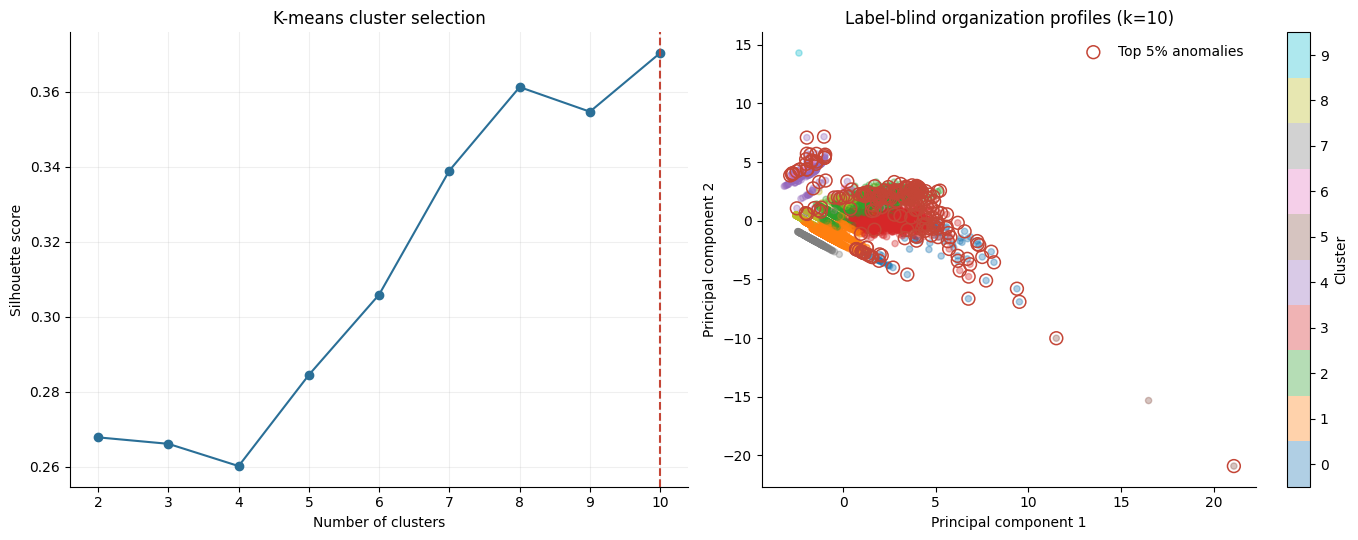

Selected k=10 with silhouette score 0.370


,organizations,anomalies,median_log_received,median_log_granted
cluster,,,,
0,63,30,19.636,16.837
1,"1,768",12,11.922,0.000
2,902,60,13.710,9.922
3,777,51,15.246,14.765
4,154,39,0.000,13.815
5,3,2,21.009,23.431
6,44,7,10.777,12.905
7,184,0,12.947,0.000
8,499,19,10.251,0.000



Blind anomaly threshold: top 5% by centroid distance
Anomalies selected: 220 of 4,395
OpenSecrets prevalence in full pool: 258/4,395 (5.9%)
OpenSecrets matches among anomalies: 23/220 (10.5%)
Recall of OpenSecrets labels: 8.9%
OpenSecrets enrichment among anomalies: 1.78x


,cluster,ein,name,anomaly_distance,in_opensecrets
0,0,232888152,VANGUARD CHARITABLE ENDOWMENT PROGRAM,20.196,False
1,4,943147856,SANDLER FOUNDATION,17.835,False
2,4,873323607,CATALYST4 INC,17.621,False
3,5,110303001,FIDELITY INVESTMENTS CHARITABLE GIFT FUN,16.750,False
4,0,237825575,NATIONAL PHILANTHROPIC TRUST,16.327,False
5,5,810739440,AMERICAN ONLINE GIVING FOUNDATION INC,15.752,False
6,0,530196605,American National Red Cross & Its Constituent Chapters and Branches,14.897,False
7,4,591314521,The Grand Boule' of Sigma Pi Phi Fraternity,14.607,False
8,4,223077558,Iota Phi Theta Fraternity Inc,14.588,False
9,4,362152330,ALPHA KAPPA ALPHA SORORITY INC,14.497,False


In [204]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Keep the clustering label-blind: no seed labels, model scores, PPR proximity,
# or political-neighbor features derived using seed exclusions.
cluster_features = STRUCTB + BEHAVB
cluster_frame = M[["ein", "name"] + cluster_features].copy()
cluster_matrix = StandardScaler().fit_transform(
    cluster_frame[cluster_features].replace([np.inf, -np.inf], np.nan).fillna(0)
)

silhouette_scores = {}
cluster_models = {}
for cluster_count in range(2, 11):
    model = KMeans(n_clusters=cluster_count, random_state=42, n_init=20)
    labels = model.fit_predict(cluster_matrix)
    silhouette_scores[cluster_count] = silhouette_score(cluster_matrix, labels)
    cluster_models[cluster_count] = model

best_cluster_count = max(silhouette_scores, key=silhouette_scores.get)
best_cluster_model = cluster_models[best_cluster_count]
cluster_labels = best_cluster_model.labels_
cluster_frame["cluster"] = cluster_labels
M["cluster"] = cluster_labels

# Distance from the assigned centroid is the unsupervised anomaly score.
assigned_centroids = best_cluster_model.cluster_centers_[cluster_labels]
cluster_frame["anomaly_distance"] = np.linalg.norm(
    cluster_matrix - assigned_centroids,
    axis=1,
)
ANOMALY_FRACTION = 0.05
anomaly_cutoff = cluster_frame["anomaly_distance"].quantile(1 - ANOMALY_FRACTION)
cluster_frame["is_anomaly"] = cluster_frame["anomaly_distance"] >= anomaly_cutoff

cluster_summary = (
    cluster_frame.groupby("cluster")
    .agg(
        organizations=("ein", "size"),
        anomalies=("is_anomaly", "sum"),
        median_log_received=("log_received", "median"),
        median_log_granted=("log_granted_out", "median"),
    )
)

embedding = PCA(n_components=2).fit_transform(cluster_matrix)
cluster_frame["pc1"] = embedding[:, 0]
cluster_frame["pc2"] = embedding[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].plot(
    list(silhouette_scores),
    list(silhouette_scores.values()),
    marker="o",
    color="#2A6F97",
)
axes[0].axvline(best_cluster_count, color="#C44536", linestyle="--", linewidth=1.5)
axes[0].set_title("K-means cluster selection")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Silhouette score")
axes[0].set_xticks(list(silhouette_scores))
axes[0].grid(alpha=0.2)

cluster_scatter = axes[1].scatter(
    cluster_frame.pc1,
    cluster_frame.pc2,
    c=cluster_frame.cluster,
    cmap="tab10",
    vmin=-0.5,
    vmax=best_cluster_count - 0.5,
    s=20,
    alpha=0.35,
)
anomaly_points = cluster_frame[cluster_frame.is_anomaly]
axes[1].scatter(
    anomaly_points.pc1,
    anomaly_points.pc2,
    facecolors="none",
    edgecolors="#C44536",
    s=85,
    linewidth=1.1,
    label=f"Top {ANOMALY_FRACTION:.0%} anomalies",
)
axes[1].set_title(f"Label-blind organization profiles (k={best_cluster_count})")
axes[1].set_xlabel("Principal component 1")
axes[1].set_ylabel("Principal component 2")
axes[1].legend(frameon=False, loc="best")
fig.colorbar(
    cluster_scatter,
    ax=axes[1],
    ticks=range(best_cluster_count),
    label="Cluster",
)

for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

print(
    f"Selected k={best_cluster_count} with silhouette score "
    f"{silhouette_scores[best_cluster_count]:.3f}"
)
display(
    cluster_summary.style.format({
        "organizations": "{:,.0f}",
        "anomalies": "{:,.0f}",
        "median_log_received": "{:.3f}",
        "median_log_granted": "{:.3f}",
        "median_global_pagerank": "{:.2e}",
    })
)

# Freeze the anomaly set before adding the external OpenSecrets label.
blind_anomalies = (
    cluster_frame.loc[
        cluster_frame.is_anomaly,
        ["cluster", "ein", "name", "anomaly_distance"],
    ]
    .sort_values("anomaly_distance", ascending=False)
    .reset_index(drop=True)
)
blind_anomalies["in_opensecrets"] = blind_anomalies["ein"].isin(seed_set)

pool_opensecrets = int(cluster_frame["ein"].isin(seed_set).sum())
anomaly_opensecrets = int(blind_anomalies.in_opensecrets.sum())
pool_rate = pool_opensecrets / len(cluster_frame)
anomaly_rate = anomaly_opensecrets / len(blind_anomalies)
anomaly_recall = anomaly_opensecrets / pool_opensecrets if pool_opensecrets else 0.0
enrichment = anomaly_rate / pool_rate if pool_rate else np.nan

print(f"\nBlind anomaly threshold: top {ANOMALY_FRACTION:.0%} by centroid distance")
print(f"Anomalies selected: {len(blind_anomalies):,} of {len(cluster_frame):,}")
print(f"OpenSecrets prevalence in full pool: {pool_opensecrets:,}/{len(cluster_frame):,} ({pool_rate:.1%})")
print(f"OpenSecrets matches among anomalies: {anomaly_opensecrets:,}/{len(blind_anomalies):,} ({anomaly_rate:.1%})")
print(f"Recall of OpenSecrets labels: {anomaly_recall:.1%}")
print(f"OpenSecrets enrichment among anomalies: {enrichment:.2f}x")

display(
    blind_anomalies.head(25).style.format({
        "anomaly_distance": "{:.3f}",
    })
)

### What the blind check found

Because the clustering never saw the labels, the overlap it finds is a fair test. When we flag the top 5% most unusual organizations by distance from their cluster centre, 23 of the known dark-money groups show up among 220 anomalies. That is 10.5% of the anomalies against 5.9% of the pool, a 1.78x enrichment, but it only catches about one in eleven labels.

So it is a real signal, but a rough one. Most of the top anomalies are donor-advised funds, universities, and large charities that are unusual for their cluster but not political. Distance from the centre is useful as a supporting flag, but the supervised model and the direct political links are better for ranking.


## The real test: can it find groups it never saw?

Out-of-fold scoring already keeps the model from memorising its training set, but we can be stricter. Here we remove 40% of the known dark-money groups completely, from both training and the PageRank personalization, and then check whether the model can still rank them above the hard-negative pool.

Averaged over five splits, the held-out ROC-AUC is 0.885 (+/- 0.011) with a PR-AUC of 0.231 against a random baseline of about 0.024. At 200 retrieved orgs it recalls 40% of the held-out labels. The unseen seeds score a median of 0.462 versus 0.005 for hard negatives, so the gap is wide. The model has learned a pattern, not a list.


In [205]:
# Hold out 40% of known seeds (never trained, never in PPR); can the model still rank them above background?
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

nm_pool = dict(zip(M.ein, M.name))
seed_i = np.where(y == 1)[0]; neg_i = np.where(y == 0)[0]

def run_split(frac, rs):
    rng = np.random.default_rng(rs)
    hold = rng.choice(seed_i, size=max(1, int(frac * len(seed_i))), replace=False)
    train_seed = np.setdiff1d(seed_i, hold)
    pv = prox([nodes[i] for i in train_seed])                 # PPR proximity from TRAIN seeds only (leak-free)
    Xall = np.column_stack([Xbase, pv])
    train_rows = np.concatenate([train_seed, neg_i])          # held-out seeds excluded from training
    m = GBC().fit(Xall[train_rows], y[train_rows])
    sc = m.predict_proba(Xall)[:, 1]
    ev = np.concatenate([hold, neg_i]); ye = np.concatenate([np.ones(len(hold)), np.zeros(len(neg_i))])
    order = ev[np.argsort(-sc[ev])]; rankmap = {n: r for r, n in enumerate(order, 1)}
    rec = {k: float(np.mean([rankmap[i] <= k for i in hold])) for k in (50, 100, 200)}
    return hold, sc, rankmap, roc_auc_score(ye, sc[ev]), average_precision_score(ye, sc[ev]), rec

FRAC = 0.40
res = [run_split(FRAC, rs) for rs in range(5)]
aucs = [r[3] for r in res]; aps = [r[4] for r in res]
r50 = [r[5][50] for r in res]; r100 = [r[5][100] for r in res]; r200 = [r[5][200] for r in res]
ncand = len(neg_i) + int(FRAC * len(seed_i))
print(f"Hold out {int(FRAC*len(seed_i))}/{len(seed_i)} known dark-money orgs, never trained and never in the PPR.")
print(f"Averaged over 5 random splits, held-out orgs vs {len(neg_i):,} hard negatives (pool ~{ncand:,}):")
print(f"  ROC-AUC   {np.mean(aucs):.3f} +/- {np.std(aucs):.3f}")
print(f"  PR-AUC    {np.mean(aps):.3f} +/- {np.std(aps):.3f}  (random baseline ~{len(seed_i)*FRAC/ncand:.3f})")
print(f"  recall@50 {np.mean(r50):.2f}   recall@100 {np.mean(r100):.2f}   recall@200 {np.mean(r200):.2f}")

# One split in detail: which unseen dark-money orgs did the model catch vs miss?
hold, sc, rankmap, auc, ap, rec = res[0]
val = (pd.DataFrame({"ein": [nodes[i] for i in hold], "name": [nm_pool.get(nodes[i], nodes[i]) for i in hold],
                     "score": sc[hold], "rank_of_pool": [rankmap[i] for i in hold]})
       .sort_values("score", ascending=False).reset_index(drop=True))
print(f"\nSplit 0 (AUC {auc:.3f}): {len(hold)} unseen dark-money orgs, median score "
      f"{np.median(sc[hold]):.3f} vs negatives {np.median(sc[neg_i]):.3f}:")
display(val)


Hold out 103/258 known dark-money orgs, never trained and never in the PPR.
Averaged over 5 random splits, held-out orgs vs 4,137 hard negatives (pool ~4,240):
  ROC-AUC   0.885 +/- 0.011
  PR-AUC    0.231 +/- 0.037  (random baseline ~0.024)
  recall@50 0.17   recall@100 0.27   recall@200 0.40

Split 0 (AUC 0.886): 103 unseen dark-money orgs, median score 0.462 vs negatives 0.005:


,ein,name,score,rank_of_pool
0,262731617,AMERICAN ENERGY ALLIANCE,0.939461,1
1,260620554,AMERICAN FUTURE FUND,0.926254,2
2,540978858,The Conservative Caucus,0.916618,4
3,850604101,WORKMONEY INC,0.901656,5
4,264683543,American Encore,0.890563,8
...,...,...,...,...
98,380826778,MICHIGAN CREDIT UNION LEAGUE,0.003515,2410
99,207472471,National Organization For Marriage Education Fund,0.003282,2446
100,591391115,PLANNED PARENTHOOD OF SOUTH FLORIDA AND THE TR...,0.003175,2471
101,264489456,GRANITE STATE PROGRESS,0.001956,2928


## Does the political-neighbour feature help?

Some of the earlier misses are trade groups -- credit-union leagues, chambers, realtor associations. They do not show the usual conduit money pattern, but they keep clearly political company. The political-neighbour feature measures what share of an organization's grant partners are (c)(4)s, (c)(6)s, and 527s, with the labels themselves removed so there is no leak.

Adding it moves OOF ROC-AUC from 0.874 to 0.875 -- barely measurable -- but PR-AUC goes from 0.275 to 0.306, an 11-point jump on the harder precision-recall task. On the held-out splits recall@200 ticks from 0.38 to 0.40. The ROC headline looks flat, but the feature is doing real work at the top of the ranking where it counts.


In [206]:
# Ablation: model WITHOUT political-neighbor (structural+behaviour) vs WITH it (Xbase, the full model).
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score

Xno = M[STRUCTB + BEHAVB].fillna(0).values          # full model minus the political-neighbor block
cv = StratifiedKFold(5, shuffle=True, random_state=42)
def _oof(Xb):
    oof = np.zeros(len(nodes))
    for tr, te in cv.split(Xb, y):
        tp = [nodes[i] for i in tr if y[i] == 1]
        Xp = np.column_stack([Xb, prox(tp)])
        oof[te] = GBC().fit(Xp[tr], y[tr]).predict_proba(Xp[te])[:, 1]
    return oof
print(f"{'feature set':34s} {'OOF ROC-AUC':>11} {'OOF PR-AUC':>10}")
for tag, Xb in [("PPR + base", Xno), ("PPR + base + political-neighbor", Xbase)]:
    o = _oof(Xb)
    print(f"{tag:34s} {roc_auc_score(y, o):>11.3f} {average_precision_score(y, o):>10.3f}")

seed_i = np.where(y == 1)[0]; neg_i = np.where(y == 0)[0]
def _holdout(Xb, frac=0.40):
    aucs, recs = [], []
    for rs in range(5):
        rng = np.random.default_rng(rs)
        hold = rng.choice(seed_i, size=int(frac * len(seed_i)), replace=False)
        tr_seed = np.setdiff1d(seed_i, hold)
        Xall = np.column_stack([Xb, prox([nodes[i] for i in tr_seed])])
        rows = np.concatenate([tr_seed, neg_i])
        sc = GBC().fit(Xall[rows], y[rows]).predict_proba(Xall)[:, 1]
        ev = np.concatenate([hold, neg_i]); ye = np.concatenate([np.ones(len(hold)), np.zeros(len(neg_i))])
        aucs.append(roc_auc_score(ye, sc[ev]))
        order = ev[np.argsort(-sc[ev])]; rk = {n: r for r, n in enumerate(order, 1)}
        recs.append(np.mean([rk[i] <= 200 for i in hold]))
    return np.mean(aucs), np.std(aucs), np.mean(recs)
print()
for tag, Xb in [("base", Xno), ("+ political-neighbor", Xbase)]:
    a, s, r = _holdout(Xb)
    print(f"held-out  {tag:22s} ROC-AUC {a:.3f} Ã‚Â± {s:.3f}   recall@200 {r:.2f}")


feature set                        OOF ROC-AUC OOF PR-AUC
PPR + base                               0.874      0.275
PPR + base + political-neighbor          0.875      0.306

held-out  base                   ROC-AUC 0.882 Ã‚Â± 0.014   recall@200 0.38
held-out  + political-neighbor   ROC-AUC 0.885 Ã‚Â± 0.011   recall@200 0.40


## Takeaways and next steps

What we found:

- The known dark-money groups sit in a distinct part of the 2023-2024 grant network, and the model learns that pattern instead of just memorising the list. It still ranks held-out groups well above the hard-negative background.
- No single signal does the work. Tax status is a strong prior (heavy on (c)(4) and 527, light on (c)(3)), conduit structure from the grant network adds the behaviour, and closeness to other seeds adds the network view. Together they separate real conduits from large but apolitical institutions.
- The transparency index independently validates the top leads: organizations the model ranks high tend to score high on opacity too.

How to use it:

- Treat `leads` as a review queue, not an answer. Work down it by score, and use the interactive graphs and the transparency index to decide which names are worth a closer look.
- The leads the model likes but that have no outside support are where a person should spend time first.
- To refresh, update the OpenSecrets label file and the yearly parquet data, then run the notebook top to bottom. Changing `YEARS` points the whole pipeline at a different cycle.
- Possible extensions: add more label sources to widen the seed set, add shared board members or officers as another link between organizations, or track how a lead's score changes from one year to the next.

One caveat to keep in mind: every score here is a lead, not a conclusion. The point of the pipeline is to narrow tens of thousands of organizations down to a short list worth investigating. The final call still belongs to a person reading the filings.
